In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_sales.csv to ecommerce_sales (3).csv


In [28]:
import pandas as pd

df = pd.read_csv("ecommerce_sales.csv")

df.head()

,Order_ID,Date,Product,Category,Quantity,Price
0,1001,05-01-2025,Laptop,Electronics,1,50000
1,1002,06-01-2025,Headphones,Electronics,2,1500
2,1003,08-01-2025,T-Shirt,Clothing,3,800
3,1004,10-01-2025,Shoes,Footwear,1,2500
4,1005,12-01-2025,Mobile Phone,Electronics,1,20000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  30 non-null     int64 
 1   Date      30 non-null     object
 2   Product   30 non-null     object
 3   Category  30 non-null     object
 4   Quantity  30 non-null     int64 
 5   Price     30 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 1.5+ KB


In [4]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Product,0
Category,0
Quantity,0
Price,0


In [5]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Order_ID,Date,Product,Category,Quantity,Price,Revenue
0,1001,05-01-2025,Laptop,Electronics,1,50000,50000
1,1002,06-01-2025,Headphones,Electronics,2,1500,3000
2,1003,08-01-2025,T-Shirt,Clothing,3,800,2400
3,1004,10-01-2025,Shoes,Footwear,1,2500,2500
4,1005,12-01-2025,Mobile Phone,Electronics,1,20000,20000


In [6]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 478300


In [7]:
top_products = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

print(top_products)

Product
T-Shirt         18
Headphones      10
Shoes            9
Backpack         7
Laptop           6
Watch            6
Mobile Phone     5
Name: Quantity, dtype: int64


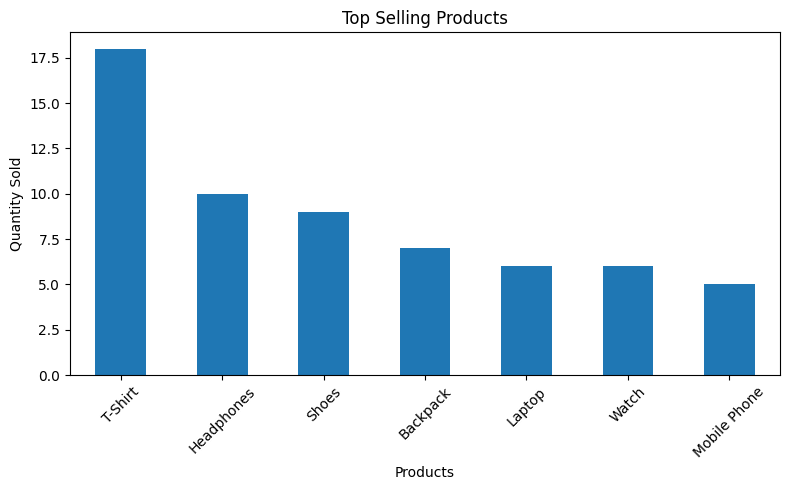

In [9]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar", figsize=(8,5))

plt.title("Top Selling Products")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Revenue"].sum()

print(monthly_sales)

Month
1    143300
2    135400
3    199600
Name: Revenue, dtype: int64


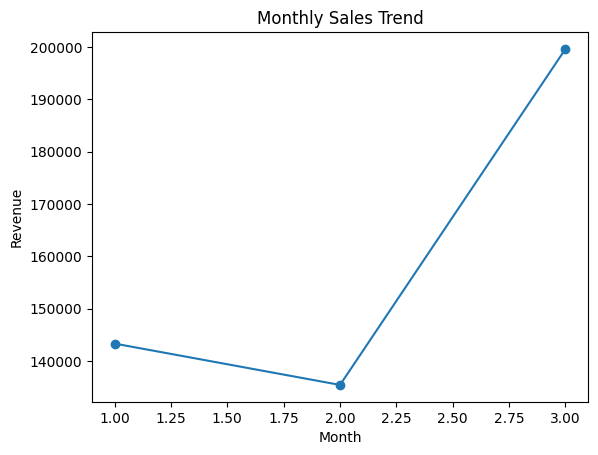

In [12]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [13]:
category_sales = df.groupby("Category")["Revenue"].sum()

print(category_sales)

Category
Accessories     18000
Bags             8400
Clothing        14400
Electronics    415000
Footwear        22500
Name: Revenue, dtype: int64


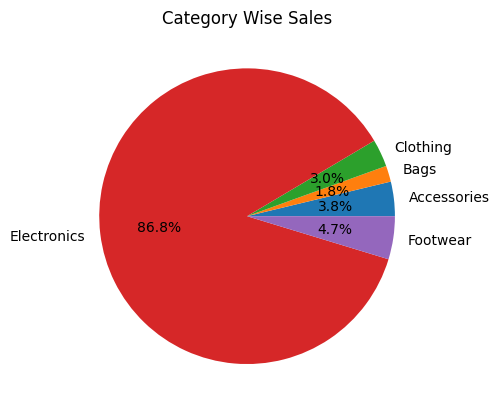

In [19]:
category_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Category Wise Sales")
plt.ylabel("")

plt.show()